# NB3 — Huấn luyện DPO (notebook chính)

**Công nghệ:** TRL 1.13 `DPOTrainer`, LoRA mới trên mô hình SFT đã gộp, β=0.1, lr=5e-6.

> **Mục tiêu:** huấn luyện adapter DPO, vẽ **riêng** hai đường `rewards/chosen` và
> `rewards/rejected` trên cả tập huấn luyện và tập held-out, rồi tự chẩn đoán xem margin
> tăng theo kiểu nào (NB0 §5).

**Ba thay đổi so với lab cũ, đều ảnh hưởng tới kết quả:**
1. **Mô hình tham chiếu (reference) = mô hình SFT.** Lab cũ chồng LoRA DPO lên LoRA SFT rồi để TRL tắt
   adapter để lấy reference, tức là so với *mô hình gốc*. Ở đây mô hình đang học (policy) là
   `models/sft-merged` + LoRA mới (khởi tạo bằng 0), và
   `precompute_ref_log_probs=True` chấm mọi cặp trước bước cập nhật đầu tiên.
2. **lr = 5e-6.** 5e-7 là mức cho tinh chỉnh toàn bộ; với LoRA và ~100 bước, reward gần như đứng yên.
3. **Eval held-out.** Cặp eval không trùng câu hỏi với huấn luyện (NB2).

In [1]:
import sys
import time
import os
from contextlib import nullcontext
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "lab22" / "config.py").exists())
sys.path.insert(0, str(ROOT))

import unsloth  # noqa: F401
import torch

from lab22 import config as C
from lab22 import data as D
from lab22 import modeling as MD

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."
assert C.SFT_MERGED.exists(), f"Run NB1 first: {C.SFT_MERGED} missing"
assert (C.PREF_DIR / "train.parquet").exists(), "Run NB2 first"
C.ensure_dirs()
print(C.summary())

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/content/day22-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!


COMPUTE_TIER=T4 base=unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit max_len=768 seed=42
SFT saillab/alpaca-vietnamese-cleaned[:1000]  PREF sailor2/sea-ultrafeedback-onpolicy (Vietnamese) train=800 eval=100
DPO beta=0.1 lr=5e-06 epochs=1.0 loss=['sigmoid']


## 1. Mô hình đang học (policy) = SFT đã gộp + LoRA mới

Không có mô hình thứ hai trong VRAM. Log-prob của reference được tính một lần
trước khi huấn luyện (lúc LoRA còn bằng 0) rồi lưu lại, nên phần VRAM tăng thêm so
với SFT chủ yếu đến từ việc giữ cả câu chosen lẫn rejected trong một batch.

In [2]:
model, tokenizer = MD.load_model(C.SFT_MERGED)
model = MD.add_lora(model)

from datasets import Dataset

train_ds = Dataset.from_parquet(str(C.PREF_DIR / "train.parquet"))
eval_ds = Dataset.from_parquet(str(C.PREF_DIR / "eval.parquet"))
print(f"train={len(train_ds)} eval={len(eval_ds)}  columns={train_ds.column_names}")

==((====))==  Unsloth 2026.10.2: Fast Qwen3 patching. Transformers: 5.17.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu118. CUDA: 7.5. CUDA Toolkit: 11.8. Triton: 3.3.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/398 [00:02<19:14,  2.91s/it]

Loading weights:   1%|          | 3/398 [00:03<05:35,  1.18it/s]

Loading weights:   1%|▏         | 5/398 [00:03<02:56,  2.22it/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 800 examples [00:00, 54953.21 examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 100 examples [00:00, 25679.94 examples/s]

train=800 eval=100  columns=['prompt', 'chosen', 'rejected', 'chat_template_kwargs']


## 2. Huấn luyện

In [3]:
from trl import DPOTrainer

args = MD.dpo_config(C.ADAPTERS / "dpo-checkpoints")
print(f"loss_type={args.loss_type} beta={args.beta} lr={args.learning_rate} "
      f"precompute_ref={args.precompute_ref_log_probs} max_length={args.max_length}")

trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
)
torch.cuda.reset_peak_memory_stats()
training_started = time.perf_counter()
save_on_cpu = os.environ.get("DPO_SAVE_ON_CPU", "0") == "1"
with torch.autograd.graph.save_on_cpu(pin_memory=True) if save_on_cpu else nullcontext():
    result = trainer.train()
train_seconds = time.perf_counter() - training_started
final_eval = trainer.evaluate()
print(f"train loss {result.training_loss:.4f} · held-out reward accuracy "
      f"{final_eval.get('eval_rewards/accuracies', float('nan')):.3f}")

loss_type=['sigmoid'] beta=0.1 lr=5e-06 precompute_ref=True max_length=768


Tokenizing train dataset (num_proc=2):   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=2):   1%|          | 9/800 [00:03<04:57,  2.66 examples/s]

Tokenizing train dataset (num_proc=2):   4%|▎         | 28/800 [00:03<01:15, 10.24 examples/s]

Tokenizing train dataset (num_proc=2):   6%|▌         | 49/800 [00:03<00:35, 21.12 examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 800 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,088,528,384 (0.81% trained)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
25,0.686667,0.685883,1.506273,145434.000000,-2.089617,-2.081246,0.617799,0.093833,0.078807,0.620000,0.015026,-389.796516,-328.490371
50,0.674485,0.665595,1.506383,278676.000000,-2.100302,-2.092764,0.618085,0.307644,0.247607,0.630000,0.060036,-387.658408,-326.802363
75,0.654381,0.655496,1.505725,423394.000000,-2.104774,-2.097353,0.618217,0.420607,0.336492,0.670000,0.084115,-386.528773,-325.913519
100,0.644966,0.653312,1.505767,557774.000000,-2.105666,-2.098467,0.618258,0.443676,0.354129,0.680000,0.089547,-386.298084,-325.737144


Training Loss,Validation Loss,Step,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
0.644966,0.653312,100,1.505767,557774.000000,-2.105666,-2.098467,0.618258,0.443676,0.354129,0.680000,0.089547,-386.298084,-325.737144


train loss 0.6739 · held-out reward accuracy 0.680


## 3. Đường cong reward (sản phẩm nộp `03-dpo-reward-curves.png`)

Implicit reward = β·log(π/π_ref) nên bắt đầu ở 0. Đọc đường *chosen*, không chỉ margin:
- chosen ↑, rejected ↓ → đúng ý đồ;
- chosen ↓, rejected ↓ nhanh hơn → **likelihood displacement** (Razin et al. 2024).

Loss ở bước đầu phải gần 0.693 (NB0 §3). Nếu không, reference đang sai.

first logged loss: 0.6935278892517089


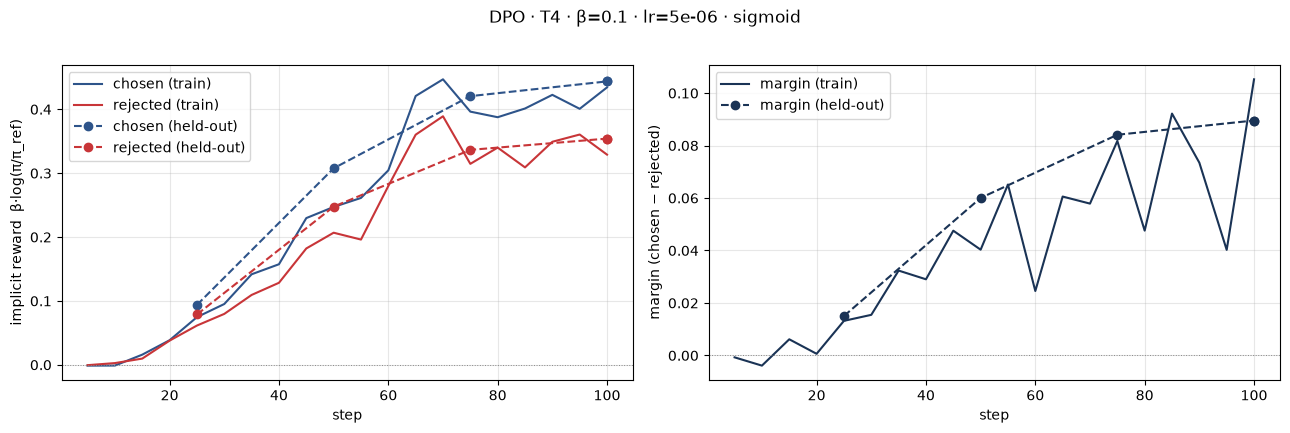

In [4]:
train_hist = MD.reward_history(trainer.state.log_history)
eval_hist = MD.reward_history(trainer.state.log_history, prefix="eval_")
title = f"DPO · {C.COMPUTE_TIER} · β={C.DPO_BETA} · lr={C.DPO_LR} · {'+'.join(C.DPO_LOSS)}"
MD.plot_rewards(train_hist, eval_hist, title, C.SCREENSHOTS / "03-dpo-reward-curves.png")

first_loss = next((r["loss"] for r in trainer.state.log_history if "loss" in r), None)
print(f"first logged loss: {first_loss}")

In [5]:
label, message = MD.diagnose(eval_hist if len(eval_hist) >= 2 else train_hist)
print(f"[{label}] {message}")

[INTENDED] Chosen +0.436 up, rejected +0.348, margin +0.088.


## 4. Lưu adapter + metrics

In [6]:
import json

trainer.model.save_pretrained(str(C.DPO_ADAPTER))
tokenizer.save_pretrained(str(C.DPO_ADAPTER))
D.save_split_fingerprint(C.PREF_DIR, C.DPO_ADAPTER)  # NB4 refuses a held-out set this adapter saw


def last(df, col):
    return float(df[col].iloc[-1]) if not df.empty and col in df else None


metrics = {
    "compute_tier": C.COMPUTE_TIER,
    "base_model": C.BASE_MODEL,
    "reference": "models/sft-merged (precomputed)",
    "pref_dataset": C.PREF_DATASET,
    "beta": C.DPO_BETA,
    "lr": C.DPO_LR,
    "loss_type": C.DPO_LOSS,
    "epochs": C.DPO_EPOCHS,
    "train_pairs": len(train_ds),
    "eval_pairs": len(eval_ds),
    "max_length": C.MAX_LEN,
    "seed": C.SEED,
    "train_seconds": train_seconds,
    "peak_vram_gb": torch.cuda.max_memory_allocated() / 1024**3,
    "optimizer_steps": trainer.state.global_step,
    "saved_tensors_on_cpu": save_on_cpu,
    "log_history": trainer.state.log_history,
    "final_train_loss": float(result.training_loss),
    "first_logged_loss": first_loss,
    "end_chosen_reward": last(train_hist, "rewards/chosen"),
    "end_rejected_reward": last(train_hist, "rewards/rejected"),
    "end_reward_gap": last(train_hist, "rewards/margins"),
    "eval_chosen_reward": final_eval.get("eval_rewards/chosen"),
    "eval_rejected_reward": final_eval.get("eval_rewards/rejected"),
    "eval_reward_gap": final_eval.get("eval_rewards/margins"),
    "eval_reward_accuracy": final_eval.get("eval_rewards/accuracies"),
    "diagnosis": label,
}
(C.DPO_ADAPTER / "dpo_metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

Unsloth: Restored added_tokens_decoder metadata in /content/day22-clean-t4/adapters/dpo/tokenizer_config.json.


{
  "compute_tier": "T4",
  "base_model": "unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit",
  "reference": "models/sft-merged (precomputed)",
  "pref_dataset": "sailor2/sea-ultrafeedback-onpolicy",
  "beta": 0.1,
  "lr": 5e-06,
  "loss_type": [
    "sigmoid"
  ],
  "epochs": 1.0,
  "train_pairs": 800,
  "eval_pairs": 100,
  "max_length": 768,
  "seed": 42,
  "train_seconds": 1396.2997153099996,
  "peak_vram_gb": 5.754496097564697,
  "optimizer_steps": 100,
  "saved_tensors_on_cpu": false,
  "log_history": [
    {
      "loss": 0.6935278892517089,
      "grad_norm": 5.278586387634277,
      "learning_rate": 2.0000000000000003e-06,
      "entropy": 1.5294797018170356,
      "num_tokens": 26931.0,
      "logits/chosen": -2.211056163276937,
      "logits/rejected": -2.1195999331512043,
      "mean_token_accuracy": 0.6120691128075123,
      "rewards/chosen": -0.0012592506885994227,
      "rewards/rejected": -0.0005335712672604132,
      "rewards/accuracies": 0.475,
      "rewards/margins":

## 5. Ghi chú vibe-coding: quét β (+6 độ chặt chẽ)

`make beta-sweep` chạy `scripts/train_dpo.py` với β ∈ {0.05, 0.1, 0.5} và lưu vào
`adapters/dpo-b*/`. `python scripts/eval_judge.py --plot-sweep` vẽ β theo margin held-out.

**Đoán trước khi xem:** β lớn giữ mô hình đang học (policy) gần reference hơn. Margin tính bằng β·log-ratio
sẽ thay đổi thế nào? Còn độ chính xác reward?

**Tiếp theo:** NB3b (so sánh RPO / SimPO-norm / LD-DPO / ORPO) hoặc NB4 (đánh giá).